# CIC-Bell-DNS-EXF-2021

## DNS Security EDA

### 목적
정상 DNS 통신과 DNS를 이용한 비정상적인 데이터 전송 및 터널링 행동의 차이를 분석한다.

### 주요 분석 대상
- 정상 DNS 행동
- 비정상 DNS Query
- DNS Tunneling
- DNS 기반 Data Exfiltration
- 시간 Window 기반 DNS 행동

### 분석 데이터 범위
본 EDA는 1차 탐색을 위해 정상 DNS 데이터(`benign_1`)와 Heavy Text 공격 데이터(`heavy_text`)를 대표 샘플로 비교하였다.

따라서 본 단계에서 확인된 Feature 차이는 최종적인 공격 특성이 아니라, 향후 전체 공격 유형 및 모델링 단계에서 검증할 **후보 Feature**로 해석한다.


## 1. 분석 환경 설정


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Stateless DNS Query 분석
단일 DNS Query의 문자열 구조와 형태적 특징을 비교한다.


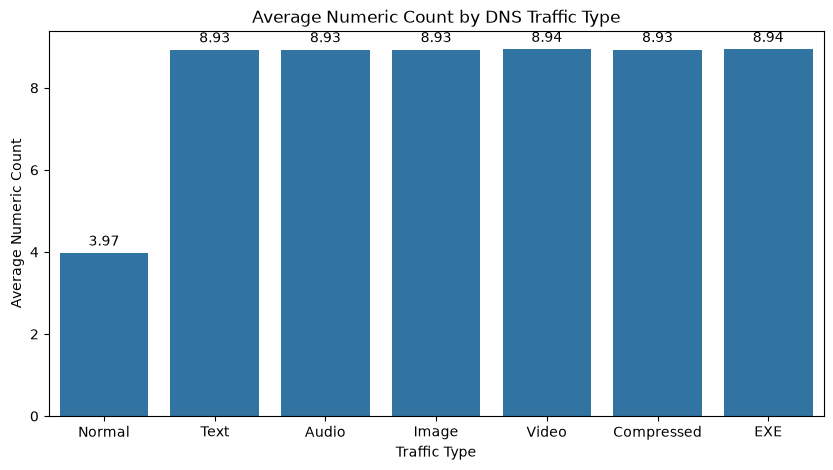

In [51]:
# Attack type files
attack_files = {
    "Text": "../data/Attack_heavy_Benign/Attacks/stateless_features-heavy_text.pcap.csv",
    "Audio": "../data/Attack_heavy_Benign/Attacks/stateless_features-heavy_audio.pcap.csv",
    "Image": "../data/Attack_heavy_Benign/Attacks/stateless_features-heavy_image.pcap.csv",
    "Video": "../data/Attack_heavy_Benign/Attacks/stateless_features-heavy_video.pcap.csv",
    "Compressed": "../data/Attack_heavy_Benign/Attacks/stateless_features-heavy_compressed.pcap.csv",
    "EXE": "../data/Attack_heavy_Benign/Attacks/stateless_features-heavy_exe.pcap.csv"
}


benign_path = "../data/Benign/stateless_features-benign_1.pcap.csv"
benign = pd.read_csv(benign_path)

numeric_data = {
    "Normal": benign["numeric"].mean()
}

benign_path = "../data/Benign/stateless_features-benign_1.pcap.csv"
benign = pd.read_csv(benign_path)

for attack_type, file_path in attack_files.items():
    df = pd.read_csv(file_path)
    numeric_data[attack_type] = df["numeric"].mean()

numeric_comparison = pd.DataFrame({
    "Type": list(numeric_data.keys()),
    "Average Numeric Count": list(numeric_data.values())
})

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=numeric_comparison,
    x="Type",
    y="Average Numeric Count"
)

ax.set_title("Average Numeric Count by DNS Traffic Type")
ax.set_xlabel("Traffic Type")
ax.set_ylabel("Average Numeric Count")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()

기존 분석에서는 대표 정상 DNS와 Heavy Text 공격을 비교하였다.

이제 분석 범위를 확장하여 Text, Audio, Image, Video, Compressed, EXE 공격 유형별로 주요 Feature의 분포 차이를 비교한다.|

### Attack Type Distribution Analysis

In [52]:
attack_files = {
    "Text": "../data/Attack_heavy_Benign/Attacks/stateless_features-heavy_text.pcap.csv",
    "Audio": "../data/Attack_heavy_Benign/Attacks/stateless_features-heavy_audio.pcap.csv",
    "Image": "../data/Attack_heavy_Benign/Attacks/stateless_features-heavy_image.pcap.csv",
    "Video": "../data/Attack_heavy_Benign/Attacks/stateless_features-heavy_video.pcap.csv",
    "Compressed": "../data/Attack_heavy_Benign/Attacks/stateless_features-heavy_compressed.pcap.csv",
    "EXE": "../data/Attack_heavy_Benign/Attacks/stateless_features-heavy_exe.pcap.csv"
}

frames = []

normal_temp = benign.copy()
normal_temp["Type"] = "Normal"
frames.append(normal_temp)

for attack_type, file_path in attack_files.items():
    temp = pd.read_csv(file_path)
    temp["Type"] = attack_type
    frames.append(temp)

combined_df = pd.concat(frames, ignore_index=True)

print(combined_df["Type"].value_counts())

Type
Normal        132499
Text           71102
Video          38012
Image          36386
Audio          35795
Compressed     35746
EXE            34629
Name: count, dtype: int64


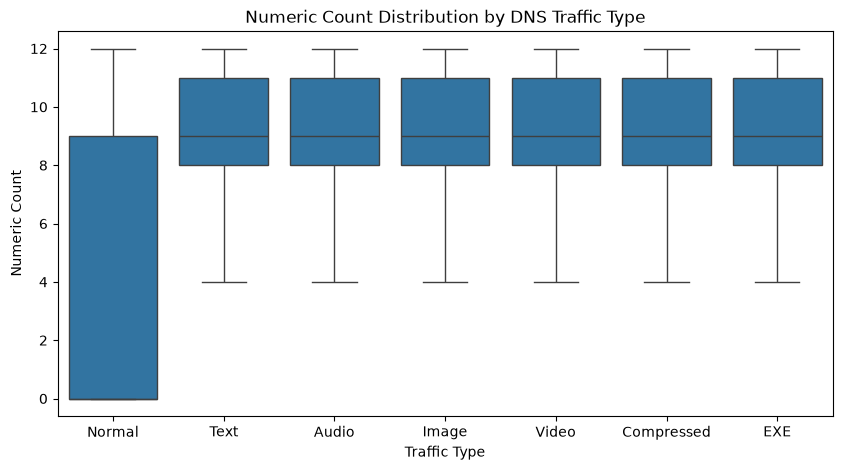

In [53]:
plt.figure(figsize=(10, 5))

ax = sns.boxplot(
    data=combined_df,
    x="Type",
    y="numeric",
    showfliers=False
)

ax.set_title("Numeric Count Distribution by DNS Traffic Type")
ax.set_xlabel("Traffic Type")
ax.set_ylabel("Numeric Count")

plt.show()

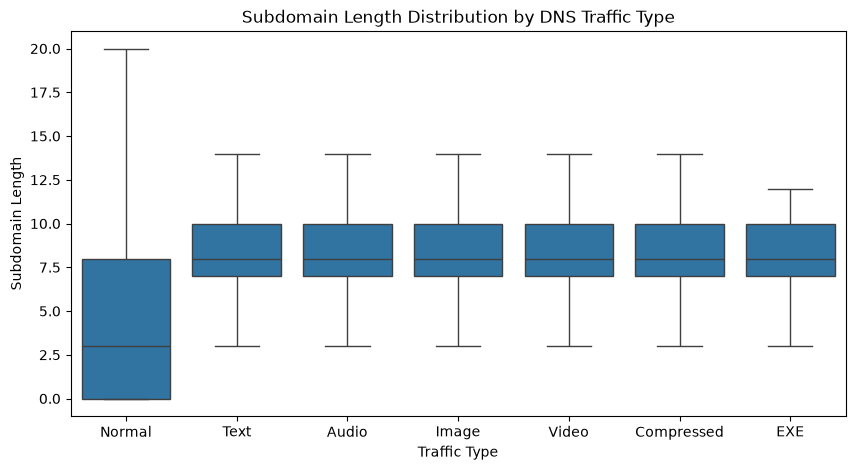

In [72]:
plt.figure(figsize=(10, 5))

ax = sns.boxplot(
    data=combined_df,
    x="Type",
    y="subdomain_length",
    showfliers=False
)

ax.set_title("Subdomain Length Distribution by DNS Traffic Type")
ax.set_xlabel("Traffic Type")
ax.set_ylabel("Subdomain Length")
plt.savefig(
    "../results/images/subdomain_length_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

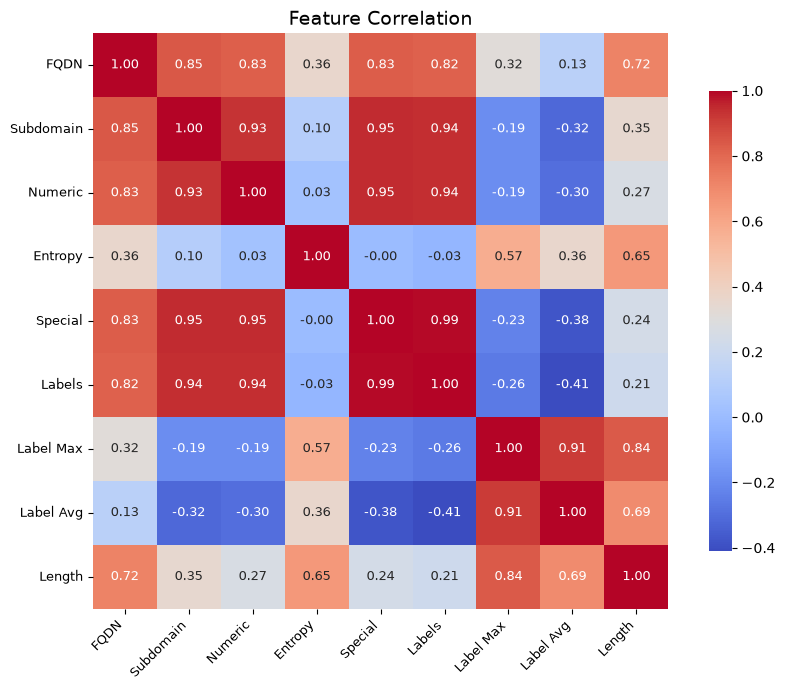

In [55]:
features = [
    "FQDN_count",
    "subdomain_length",
    "numeric",
    "entropy",
    "special",
    "labels",
    "labels_max",
    "labels_average",
    "len"
]

short_labels = {
    "FQDN_count": "FQDN",
    "subdomain_length": "Subdomain",
    "numeric": "Numeric",
    "entropy": "Entropy",
    "special": "Special",
    "labels": "Labels",
    "labels_max": "Label Max",
    "labels_average": "Label Avg",
    "len": "Length"
}

corr_matrix = benign[features].corr()

corr_short = corr_matrix.rename(
    index=short_labels,
    columns=short_labels
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_short,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig(
    "../results/images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

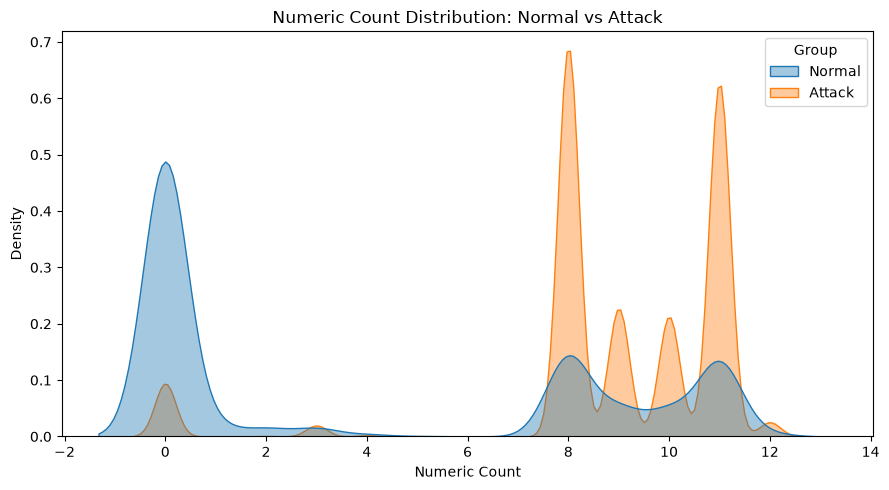

In [56]:
distribution_df = combined_df.copy()

distribution_df["Group"] = distribution_df["Type"].apply(
    lambda x: "Normal" if x == "Normal" else "Attack"
)

plt.figure(figsize=(9, 5))

sns.kdeplot(
    data=distribution_df,
    x="numeric",
    hue="Group",
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title("Numeric Count Distribution: Normal vs Attack")
plt.xlabel("Numeric Count")
plt.ylabel("Density")

plt.tight_layout()
plt.savefig(
    "../results/images/numeric_distribution_kde.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

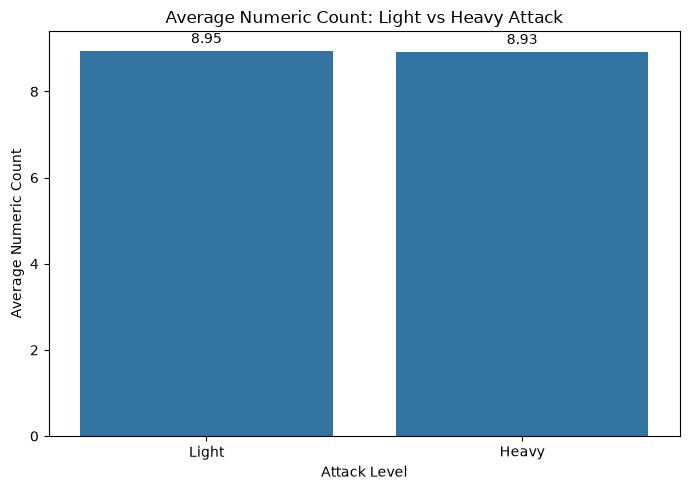

In [57]:
light_text = pd.read_csv(
    "../data/Attack_Light_Benign/Attacks/stateless_features-light_text.pcap.csv"
)

heavy_text = pd.read_csv(
    "../data/Attack_heavy_Benign/Attacks/stateless_features-heavy_text.pcap.csv"
)

light_heavy_comparison = pd.DataFrame({
    "Attack Level": ["Light", "Heavy"],
    "Average Numeric Count": [
        light_text["numeric"].mean(),
        heavy_text["numeric"].mean()
    ]
})

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=light_heavy_comparison,
    x="Attack Level",
    y="Average Numeric Count"
)

ax.set_title("Average Numeric Count: Light vs Heavy Attack")
ax.set_xlabel("Attack Level")
ax.set_ylabel("Average Numeric Count")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

### 해석

Light Text 공격과 Heavy Text 공격의 평균 `numeric` 값은 각각 약 8.95, 8.93으로 거의 차이가 없다.

이는 `numeric` Feature가 정상 DNS와 공격 DNS를 구분하는 데는 유용할 가능성이 있지만,
공격 강도인 Light와 Heavy를 구분하는 데는 제한적일 수 있음을 의미한다.

In [58]:
print("=== 정상 vs 공격 평균 비교 ===")

attack_path = "../data/Attack_heavy_Benign/Attacks/stateless_features-heavy_text.pcap.csv"
attack = pd.read_csv(attack_path)

for feature in features:
    benign_mean = benign[feature].mean()
    attack_mean = attack[feature].mean()

    print(
        f"{feature:20s} "
        f"정상: {benign_mean:.3f} | "
        f"공격: {attack_mean:.3f}"
    )

=== 정상 vs 공격 평균 비교 ===
FQDN_count           정상: 18.447 | 공격: 25.331
subdomain_length     정상: 4.020 | 공격: 8.070
numeric              정상: 3.972 | 공격: 8.927
entropy              정상: 2.439 | 공격: 2.442
special              정상: 3.296 | 공격: 5.682
labels               정상: 3.840 | 공격: 5.715
labels_max           정상: 7.904 | 공격: 7.867
labels_average       정상: 4.772 | 공격: 4.484
len                  정상: 11.277 | 공격: 13.174


### 참고: entropy
정상 DNS와 공격 DNS의 평균 entropy는 각각 약 **2.439**, **2.442**로 차이가 매우 작았다.
따라서 현재 대표 샘플 비교에서는 entropy 단독으로 정상/공격을 구분하기 어려운 것으로 보인다.


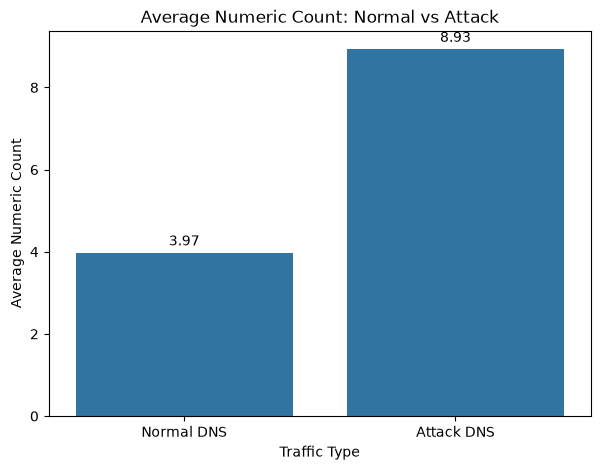

In [59]:
comparison = pd.DataFrame({
    "Type": ["Normal DNS", "Attack DNS"],
    "Average Numeric Count": [
        benign["numeric"].mean(),
        attack["numeric"].mean()
    ]
})

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=comparison,
    x="Type",
    y="Average Numeric Count"
)

ax.set_title("Average Numeric Count: Normal vs Attack")
ax.set_xlabel("Traffic Type")
ax.set_ylabel("Average Numeric Count")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()

### 해석

공격 DNS의 평균 숫자 문자 수가 정상 DNS보다 높게 나타났다.

정상 DNS는 약 3.97, 공격 DNS는 약 8.93으로 확인되었으며,
비정상 DNS Query에서 숫자 기반 문자열이 더 많이 사용되는 경향을 보였다.

이는 DNS Tunneling 및 Data Exfiltration 탐지에 활용할 수 있는 특징 후보로 볼 수 있다.

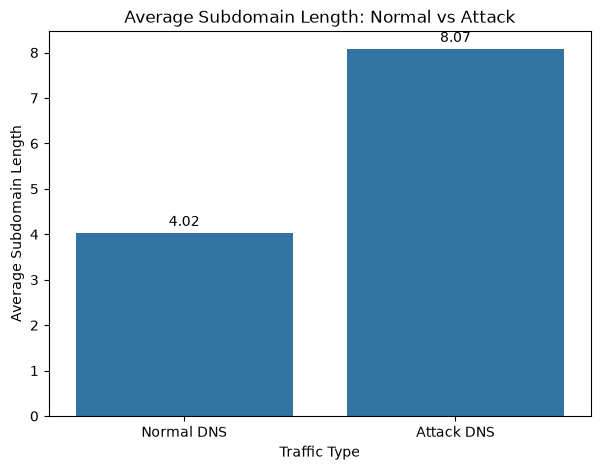

In [60]:
subdomain_comparison = pd.DataFrame({
    "Type": ["Normal DNS", "Attack DNS"],
    "Average Subdomain Length": [
        benign["subdomain_length"].mean(),
        attack["subdomain_length"].mean()
    ]
})

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=subdomain_comparison,
    x="Type",
    y="Average Subdomain Length"
)

ax.set_title("Average Subdomain Length: Normal vs Attack")
ax.set_xlabel("Traffic Type")
ax.set_ylabel("Average Subdomain Length")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()

### 해석

공격 DNS의 평균 서브도메인 길이가 정상 DNS보다 높게 나타났다.

정상 DNS는 약 4.02, 공격 DNS는 약 8.07로 확인되었으며,
공격 DNS의 서브도메인이 정상보다 약 2배 길게 나타났다.

이는 DNS Tunneling이나 Data Exfiltration 과정에서
서브도메인 영역에 추가 데이터가 포함될 가능성과 관련된 특징으로 볼 수 있다.

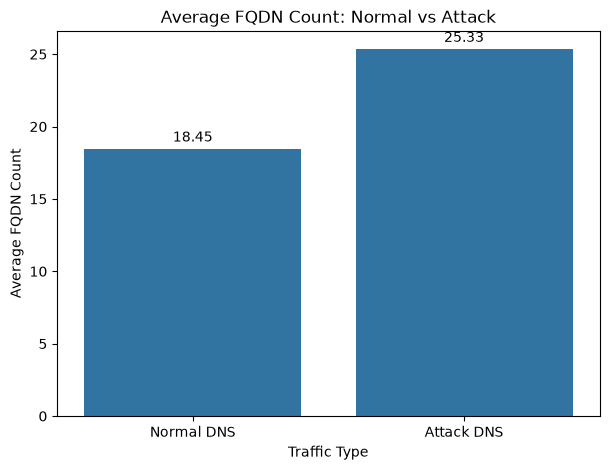

In [61]:
fqdn_comparison = pd.DataFrame({
    "Type": ["Normal DNS", "Attack DNS"],
    "Average FQDN Count": [
        benign["FQDN_count"].mean(),
        attack["FQDN_count"].mean()
    ]
})

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=fqdn_comparison,
    x="Type",
    y="Average FQDN Count"
)

ax.set_title("Average FQDN Count: Normal vs Attack")
ax.set_xlabel("Traffic Type")
ax.set_ylabel("Average FQDN Count")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()

### 해석

공격 DNS의 평균 FQDN 문자 수가 정상 DNS보다 높게 나타났다.

정상 DNS는 약 18.45, 공격 DNS는 약 25.33으로 확인되었으며,
공격 DNS에서 더 긴 DNS 이름이 사용되는 경향을 보였다.

이는 DNS Tunneling이나 Data Exfiltration 과정에서
추가 데이터가 DNS Query 이름에 포함될 가능성과 관련된 특징으로 볼 수 있다.

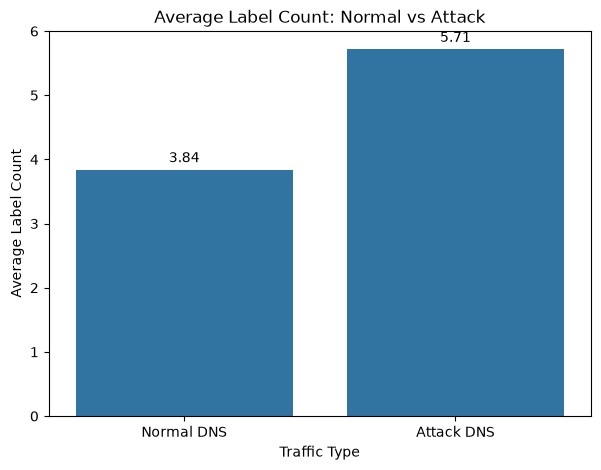

In [62]:
labels_comparison = pd.DataFrame({
    "Type": ["Normal DNS", "Attack DNS"],
    "Average Label Count": [
        benign["labels"].mean(),
        attack["labels"].mean()
    ]
})

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=labels_comparison,
    x="Type",
    y="Average Label Count"
)

ax.set_title("Average Label Count: Normal vs Attack")
ax.set_xlabel("Traffic Type")
ax.set_ylabel("Average Label Count")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()

### 해석

공격 DNS의 평균 Label 수가 정상 DNS보다 높게 나타났다.

정상 DNS는 약 3.84, 공격 DNS는 약 5.72로 확인되었으며,
공격 DNS에서 도메인 구조가 더 여러 단계로 나뉘는 경향을 보였다.

이는 DNS Tunneling이나 Data Exfiltration 과정에서
복잡한 서브도메인 구조가 사용될 가능성과 관련된 특징으로 볼 수 있다.

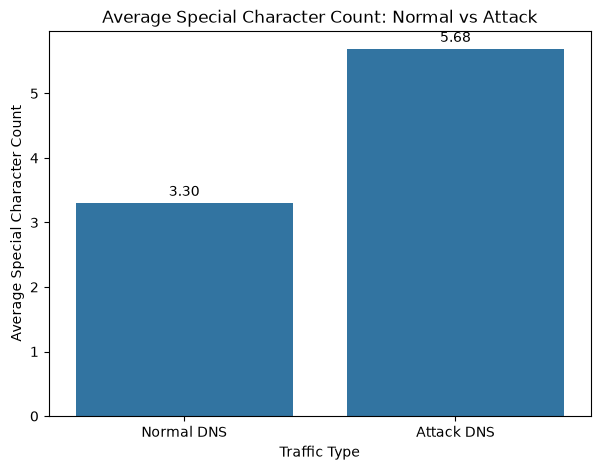

In [63]:
special_comparison = pd.DataFrame({
    "Type": ["Normal DNS", "Attack DNS"],
    "Average Special Character Count": [
        benign["special"].mean(),
        attack["special"].mean()
    ]
})

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=special_comparison,
    x="Type",
    y="Average Special Character Count"
)

ax.set_title("Average Special Character Count: Normal vs Attack")
ax.set_xlabel("Traffic Type")
ax.set_ylabel("Average Special Character Count")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()

### 해석

공격 DNS의 평균 특수문자 수가 정상 DNS보다 높게 나타났다.

정상 DNS는 약 3.30, 공격 DNS는 약 5.68로 확인되었으며,
공격 DNS Query에서 특수문자가 더 많이 사용되는 경향을 보였다.

이는 비정상 DNS 문자열 구조를 구분하는 보조 특징으로 활용할 수 있다.

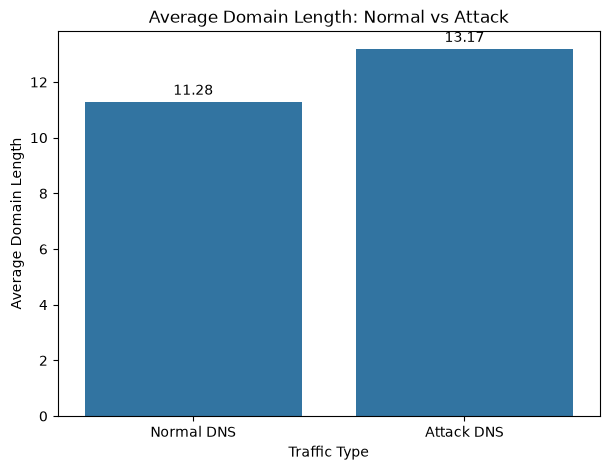

In [64]:
len_comparison = pd.DataFrame({
    "Type": ["Normal DNS", "Attack DNS"],
    "Average Domain Length": [
        benign["len"].mean(),
        attack["len"].mean()
    ]
})

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=len_comparison,
    x="Type",
    y="Average Domain Length"
)

ax.set_title("Average Domain Length: Normal vs Attack")
ax.set_xlabel("Traffic Type")
ax.set_ylabel("Average Domain Length")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()

### 해석

공격 DNS의 평균 도메인 길이가 정상 DNS보다 높게 나타났다.

정상 DNS는 약 11.28, 공격 DNS는 약 13.17로 확인되었으며,
공격 DNS에서 전체 도메인 문자열이 더 길어지는 경향을 보였다.

이는 비정상 DNS Query의 문자열 구조를 구분하는 보조 특징으로 활용할 수 있다.

## 3. Stateful / 시간 Window 기반 DNS 행동 분석
여러 DNS 관측을 묶어 계산한 TTL 및 누적 행동 특성을 비교한다.


In [65]:
stateful_benign_path = "../data/Benign/stateful_features-benign_1.pcap.csv"
stateful_attack_path = "../data/Attack_heavy_Benign/Attacks/stateful_features-heavy_text.pcap.csv"

stateful_benign = pd.read_csv(stateful_benign_path)
stateful_attack = pd.read_csv(stateful_attack_path)

print("정상 Stateful:", stateful_benign.shape)
print("공격 Stateful:", stateful_attack.shape)

print("\n컬럼 목록:")
print(stateful_benign.columns.tolist())

정상 Stateful: (52438, 27)
공격 Stateful: (18916, 27)

컬럼 목록:
['rr', 'A_frequency', 'NS_frequency', 'CNAME_frequency', 'SOA_frequency', 'NULL_frequency', 'PTR_frequency', 'HINFO_frequency', 'MX_frequency', 'TXT_frequency', 'AAAA_frequency', 'SRV_frequency', 'OPT_frequency', 'rr_type', 'rr_count', 'rr_name_entropy', 'rr_name_length', 'distinct_ns', 'distinct_ip', 'unique_country', 'unique_asn', 'distinct_domains', 'reverse_dns', 'a_records', 'unique_ttl', 'ttl_mean', 'ttl_variance']


In [66]:
stateful_numeric_features = [
    "ttl_mean",
    "ttl_variance"
]

print("=== Stateful 정상 vs 공격 평균 비교 ===")

for feature in stateful_numeric_features:
    benign_mean = stateful_benign[feature].mean()
    attack_mean = stateful_attack[feature].mean()

    print(
        f"{feature:15s} "
        f"정상: {benign_mean:.3f} | "
        f"공격: {attack_mean:.3f}"
    )

=== Stateful 정상 vs 공격 평균 비교 ===
ttl_mean        정상: 92.196 | 공격: 12.152
ttl_variance    정상: 2.807 | 공격: 0.003


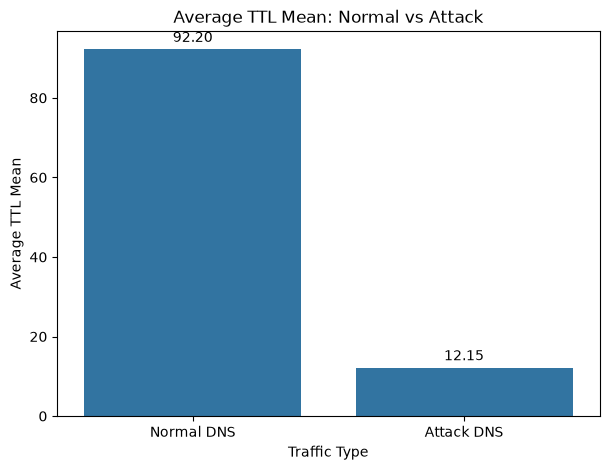

In [67]:
ttl_mean_comparison = pd.DataFrame({
    "Type": ["Normal DNS", "Attack DNS"],
    "Average TTL Mean": [
        stateful_benign["ttl_mean"].mean(),
        stateful_attack["ttl_mean"].mean()
    ]
})

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=ttl_mean_comparison,
    x="Type",
    y="Average TTL Mean"
)

ax.set_title("Average TTL Mean: Normal vs Attack")
ax.set_xlabel("Traffic Type")
ax.set_ylabel("Average TTL Mean")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()

### 해석

정상 DNS와 공격 DNS의 평균 TTL에서 큰 차이가 나타났다.

정상 DNS는 약 92.20, 공격 DNS는 약 12.15로 확인되었으며,
공격 DNS의 평균 TTL이 정상보다 크게 낮게 나타났다.

이는 시간 Window 기반 DNS 행동에서 TTL 패턴이
정상과 공격을 구분하는 중요한 특징 후보가 될 수 있음을 보여준다.

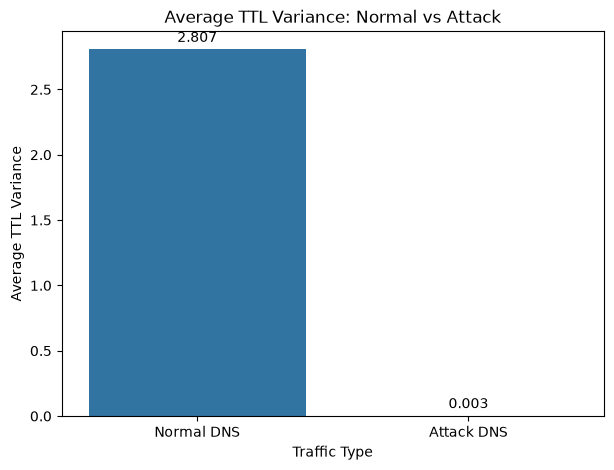

In [68]:
ttl_variance_comparison = pd.DataFrame({
    "Type": ["Normal DNS", "Attack DNS"],
    "Average TTL Variance": [
        stateful_benign["ttl_variance"].mean(),
        stateful_attack["ttl_variance"].mean()
    ]
})

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=ttl_variance_comparison,
    x="Type",
    y="Average TTL Variance"
)

ax.set_title("Average TTL Variance: Normal vs Attack")
ax.set_xlabel("Traffic Type")
ax.set_ylabel("Average TTL Variance")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.show()

### 해석

정상 DNS와 공격 DNS의 TTL 분산에서 큰 차이가 나타났다.

정상 DNS는 약 2.807, 공격 DNS는 약 0.003으로 확인되었으며,
공격 DNS에서는 TTL 값의 변동성이 매우 낮게 나타났다.

이는 시간 Window 기반 DNS 행동에서 TTL 변화 패턴이
정상과 공격을 구분하는 중요한 특징 후보가 될 수 있음을 보여준다.

### unique_ttl 전처리
`unique_ttl`은 리스트 형태의 문자열로 저장되어 있어 직접 평균을 계산할 수 없다.
따라서 각 행의 리스트에 포함된 TTL 항목 수를 `unique_ttl_count`로 변환하여 비교하였다.


In [69]:
import ast

def count_ttl_values(value):
    try:
        return len(ast.literal_eval(value))
    except:
        return 0

stateful_benign["unique_ttl_count"] = (
    stateful_benign["unique_ttl"].apply(count_ttl_values)
)

stateful_attack["unique_ttl_count"] = (
    stateful_attack["unique_ttl"].apply(count_ttl_values)
)

print(
    "정상 unique_ttl 개수 평균:",
    stateful_benign["unique_ttl_count"].mean()
)

print(
    "공격 unique_ttl 개수 평균:",
    stateful_attack["unique_ttl_count"].mean()
)

정상 unique_ttl 개수 평균: 2.526412143865136
공격 unique_ttl 개수 평균: 3.7576126030873334


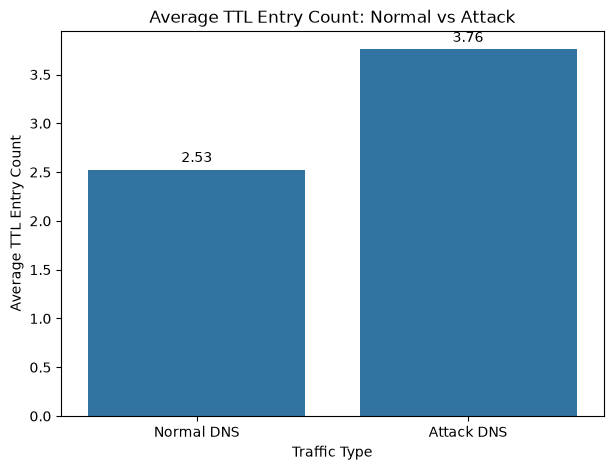

In [70]:
unique_ttl_comparison = pd.DataFrame({
    "Type": ["Normal DNS", "Attack DNS"],
    "Average TTL Entry Count": [
        stateful_benign["unique_ttl_count"].mean(),
        stateful_attack["unique_ttl_count"].mean()
    ]
})

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=unique_ttl_comparison,
    x="Type",
    y="Average TTL Entry Count"
)

ax.set_title("Average TTL Entry Count: Normal vs Attack")
ax.set_xlabel("Traffic Type")
ax.set_ylabel("Average TTL Entry Count")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()

### 해석

공격 DNS에서 관측된 TTL 항목 수가 정상 DNS보다 높게 나타났다.

정상 DNS는 약 2.53, 공격 DNS는 약 3.76으로 확인되었으며,
시간 Window 안에서 공격 DNS의 TTL 관련 기록이 더 많이 나타나는 경향을 보였다.

다만 원본 `unique_ttl` 컬럼이 리스트 형태의 문자열로 저장되어 있어,
이번 분석에서는 리스트에 포함된 TTL 항목 수를 기준으로 비교했다.

## 4. 제외 / 참고 Feature


In [71]:
print("정상 distinct_ip 고유값:")
print(stateful_benign["distinct_ip"].value_counts().head(10))

print("\n공격 distinct_ip 고유값:")
print(stateful_attack["distinct_ip"].value_counts().head(10))

정상 distinct_ip 고유값:
distinct_ip
set()    52438
Name: count, dtype: int64

공격 distinct_ip 고유값:
distinct_ip
set()    18916
Name: count, dtype: int64


### distinct_ip 제외 근거
대표 정상/공격 데이터에서 `distinct_ip` 값이 모두 `set()`으로 확인되었다.
현재 비교에서는 변별 정보가 없으므로 핵심 Feature 후보에서 제외하였다.


## 5. EDA 요약

정상 DNS와 공격 DNS를 비교한 결과, **DNS Query 문자열 구조**와 **시간 Window 기반 TTL 행동**에서 차이가 확인되었다.

### 주요 Feature 후보
- `numeric`
- `subdomain_length`
- `FQDN_count`
- `labels`
- `special`
- `len`
- `ttl_mean`
- `ttl_variance`
- `unique_ttl_count`

### 우선순위가 낮거나 제외한 Feature
- `entropy`: 정상/공격 평균 차이가 매우 작음
- `distinct_ip`: 대표 데이터에서 모든 값이 `set()`으로 확인됨

> EDA에서 차이가 보인 Feature는 중요도가 확정된 변수가 아니라, 모델링 단계에서 검증할 후보 Feature이다.


### 확장 분석 결과

- 공격 유형별 비교에서 `numeric`과 `subdomain_length`는 정상 DNS와 공격 DNS 사이에서 분포 차이가 확인되었다.
- Feature Correlation 분석에서는 일부 변수 간 높은 상관관계가 확인되어, 모델링 단계에서 중복 정보 여부를 검토할 필요가 있다.
- KDE 분포 비교에서는 `numeric` 값이 정상 DNS와 공격 DNS에서 서로 다른 분포를 보였다.
- Light Text와 Heavy Text 공격의 평균 `numeric` 값은 거의 동일하게 나타나, 해당 Feature는 공격 강도 구분보다는 정상/공격 구분에 더 적합할 가능성이 있다.

## 6. 분석 한계

- 현재 EDA는 전체 데이터셋의 모든 조합을 완전히 검증한 분석은 아니며, 일부 대표 정상/공격 데이터와 주요 공격 유형을 중심으로 수행하였다.
- EDA에서 확인된 Feature 차이는 머신러닝 모델에서의 중요도를 의미하지 않으며, 실제 유효성은 모델링 단계에서 추가 검증이 필요하다.
- 일부 Feature 간 높은 상관관계가 확인되어, 모델 학습 시 중복 정보가 성능에 미치는 영향을 확인할 필요가 있다.
- `distinct_ip`는 대표 데이터에서 대부분 `set()` 값으로 확인되어 현재 분석에서는 핵심 Feature 후보에서 제외하였다.
- Light와 Heavy 공격 비교는 현재 Text 공격을 중심으로 확인했기 때문에, 다른 공격 유형에서도 동일한 경향이 나타나는지는 추가 검증이 필요하다.